In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
(X_train,y_train),(X_test,y_test) = tf.keras.datasets.cifar10.load_data()

In [6]:
X_train.shape

(50000, 32, 32, 3)

In [7]:
y_train.shape

(50000, 1)

In [8]:
y_train[0:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [12]:
def plot_sample(index):
  plt.figure(figsize= (10,1))
  plt.imshow(X_train[index])

In [16]:
import matplotlib.pyplot as plt

In [18]:
classes= ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

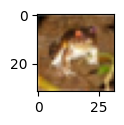

In [17]:
plot_sample(0)

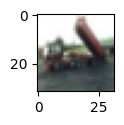

In [19]:
plot_sample(2)

In [20]:
classes[y_train[2][0]]

'truck'

In [22]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [23]:
X_train_scaled.shape

(50000, 32, 32, 3)

In [31]:
#one-hot encoding
from tensorflow import keras

y_train_categorical=keras.utils.to_categorical(
    y_train, num_classes=10
)
y_train_categorical[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [33]:
y_test_categorical=keras.utils.to_categorical(
    y_test, num_classes=10
)



In [34]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [36]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000,activation='relu'),
    keras.layers.Dense(1000,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

model.compile(optimizer='SGD',loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(X_train_scaled,y_train_categorical,epochs=50)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3045 - loss: 1.9340
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4194 - loss: 1.6384
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4558 - loss: 1.5430
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4766 - loss: 1.4886
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.4956 - loss: 1.4316
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5110 - loss: 1.3957
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5281 - loss: 1.3460
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5435 - loss: 1.3114
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5488 - loss: 1.2823
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5633 - loss: 1.2498
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5785 - loss: 1.2181
Epoch 12/50
1563/1563 ━━━━━━━

In [37]:
model.predict(X_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[4.19239312e-01, 6.67036474e-01, 8.68416488e-01, ...,
        2.50534067e-04, 4.60814834e-01, 6.38846355e-03],
       [5.43164432e-01, 9.87313330e-01, 6.98446780e-02, ...,
        2.84099936e-01, 9.99978423e-01, 9.97468472e-01],
       [9.89377677e-01, 9.60725904e-01, 1.14902064e-01, ...,
        7.85271347e-01, 9.99365151e-01, 8.90819788e-01],
       ...,
       [4.72674280e-01, 3.54748452e-03, 9.61627245e-01, ...,
        8.19798827e-01, 7.34426737e-01, 2.64067445e-02],
       [2.96256393e-01, 6.15775846e-02, 7.68188417e-01, ...,
        4.58443820e-01, 1.73947513e-02, 1.91999401e-03],
       [6.41991869e-02, 1.81126036e-02, 9.02831376e-01, ...,
        9.90514994e-01, 1.08496867e-01, 2.50441819e-01]], dtype=float32)

In [42]:
classes[y_test[1][0]]

'ship'

In [43]:
classes[np.argmax(model.predict(X_test_scaled)[1])]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


'ship'

In [44]:
#to calculate accuracy
model.evaluate(X_test_scaled,y_test_categorical)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5593 - loss: 1.6799


[1.6927359104156494, 0.5476999878883362]

In [46]:
def get_model():
  model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000,activation='relu'),
    keras.layers.Dense(1000,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

  model.compile(optimizer='SGD',loss='categorical_crossentropy',metrics=['accuracy'])

  return model

In [47]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
  cpu_model=get_model()
  cpu_model.fit(X_train_scaled,y_train_categorical,
                epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 116s 74ms/step - accuracy: 0.3034 - loss: 1.9323
1min 57s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [48]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
  cpu_model=get_model()
  cpu_model.fit(X_train_scaled,y_train_categorical,
                epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3039 - loss: 1.9307
8.66 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
